# Modelling TREFMXAV_U in Manchester across climate scenarios  

This notebook evaluates whether TREFMXAV_U can be predicted across six climate scenarios using other projected climate variables.

## Workflow  

1. Load preprocessed monthly dataset.
2. Convert to modelling DataFrame.
3. Engineer features.
4. Define rolling time-series CV folds.
5. Train and evaluate XGBoost.
6. Compare against linear and ridge baselines.
7. Inspect feature importance.
8. Fit a final model and generate predictions for 2050 - 2080.

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge
from xgboost import XGBRegressor

from src.config import INTERIM_DATA_DIR, FOLDS, TARGET
from src.features import add_time_features, add_wind_speed
from src.evaluation import regression_metrics

/Users/jacobwoodland/Semester 2/EART60702/Assignment 2/Project Folder/eds_project2


In [2]:
# Load preprocessed monthly dataset
# This dataset was created from raw NetCFD files using the preprocessing script.
# Always-missing target cells were removed before monthly aggregation.

monthly_path = INTERIM_DATA_DIR / "monthly_dataset.nc"
monthly = xr.open_dataset(monthly_path)

monthly

<xarray.Dataset> Size: 8MB
Dimensions:     (scenario: 6, time: 900, cell: 42)
Coordinates:
  * scenario    (scenario) <U3 72B '003' '004' '005' '006' '007' '008'
  * time        (time) object 7kB 2006-01-01 00:00:00 ... 2080-12-01 00:00:00
    lat         (cell) float32 168B ...
    lon         (cell) float32 168B ...
Dimensions without coordinates: cell
Data variables:
    TREFMXAV_U  (scenario, time, cell) float32 907kB ...
    TREFHT      (scenario, time, cell) float32 907kB ...
    FLNS        (scenario, time, cell) float32 907kB ...
    FSNS        (scenario, time, cell) float32 907kB ...
    PRECT       (scenario, time, cell) float32 907kB ...
    PRSN        (scenario, time, cell) float32 907kB ...
    QBOT        (scenario, time, cell) float32 907kB ...
    UBOT        (scenario, time, cell) float32 907kB ...
    VBOT        (scenario, time, cell) float32 907kB ...

In [3]:
# Convert to DataFrame

df = monthly.to_dataframe().reset_index()
df = df.drop(columns=["cell"], errors="ignore")

print(df.shape)
print(df.columns.tolist())
df.head()

(226800, 13)
['scenario', 'time', 'TREFMXAV_U', 'TREFHT', 'FLNS', 'FSNS', 'PRECT', 'PRSN', 'QBOT', 'UBOT', 'VBOT', 'lat', 'lon']


,scenario,time,TREFMXAV_U,TREFHT,FLNS,FSNS,PRECT,PRSN,QBOT,UBOT,VBOT,lat,lon
0,003,2006-01-01 00:00:00,283.507294,281.526642,46.048908,33.531834,3.500528e-07,3.125463e-14,0.005597,-0.981807,3.017333,49.476440,358.75
1,003,2006-01-01 00:00:00,284.463287,282.865601,52.176460,31.705431,8.714903e-07,1.205316e-13,0.005702,-0.244303,3.062173,50.418850,355.00
2,003,2006-01-01 00:00:00,284.273468,282.476929,49.989704,31.037649,6.878103e-07,3.282645e-14,0.005689,-0.639774,2.568420,50.418850,356.25
3,003,2006-01-01 00:00:00,284.059296,282.518463,51.271503,33.134323,5.260298e-07,3.948641e-14,0.005678,-0.480835,2.984100,50.418850,357.50
4,003,2006-01-01 00:00:00,283.649017,280.734863,34.957695,25.128208,8.111509e-07,2.320830e-13,0.005345,-0.253848,2.523335,51.361256,356.25


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 226800 entries, 0 to 226799
Data columns (total 13 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   scenario    226800 non-null  str    
 1   time        226800 non-null  object 
 2   TREFMXAV_U  226800 non-null  float32
 3   TREFHT      226800 non-null  float32
 4   FLNS        226800 non-null  float32
 5   FSNS        226800 non-null  float32
 6   PRECT       226800 non-null  float32
 7   PRSN        226800 non-null  float32
 8   QBOT        226800 non-null  float32
 9   UBOT        226800 non-null  float32
 10  VBOT        226800 non-null  float32
 11  lat         226800 non-null  float32
 12  lon         226800 non-null  float32
dtypes: float32(11), object(1), str(1)
memory usage: 13.7+ MB


In [5]:
df.isna().sum().sort_values(ascending=False)

scenario      0
time          0
TREFMXAV_U    0
TREFHT        0
FLNS          0
FSNS          0
PRECT         0
PRSN          0
QBOT          0
UBOT          0
VBOT          0
lat           0
lon           0
dtype: int64

In [6]:
df[TARGET].describe()

count    226800.000000
mean        288.421143
std           4.521397
min         276.406036
25%         284.623131
50%         287.853500
75%         292.176773
max         304.135345
Name: TREFMXAV_U, dtype: float64

The monthly dataset should contain no structural missingness in the target variable for the retained cells.

In [7]:
# Feature engineering
# Calendar features and derived wind speed

df = add_time_features(df)
df = add_wind_speed(df)

df.head()

,scenario,time,TREFMXAV_U,TREFHT,FLNS,FSNS,PRECT,PRSN,QBOT,UBOT,VBOT,lat,lon,year,month,monthly_sin,monthly_cos,wind_speed
0,003,2006-01-01 00:00:00,283.507294,281.526642,46.048908,33.531834,3.500528e-07,3.125463e-14,0.005597,-0.981807,3.017333,49.476440,358.75,2006,1,0.5,0.866025,3.173049
1,003,2006-01-01 00:00:00,284.463287,282.865601,52.176460,31.705431,8.714903e-07,1.205316e-13,0.005702,-0.244303,3.062173,50.418850,355.00,2006,1,0.5,0.866025,3.071903
2,003,2006-01-01 00:00:00,284.273468,282.476929,49.989704,31.037649,6.878103e-07,3.282645e-14,0.005689,-0.639774,2.568420,50.418850,356.25,2006,1,0.5,0.866025,2.646902
3,003,2006-01-01 00:00:00,284.059296,282.518463,51.271503,33.134323,5.260298e-07,3.948641e-14,0.005678,-0.480835,2.984100,50.418850,357.50,2006,1,0.5,0.866025,3.022591
4,003,2006-01-01 00:00:00,283.649017,280.734863,34.957695,25.128208,8.111509e-07,2.320830e-13,0.005345,-0.253848,2.523335,51.361256,356.25,2006,1,0.5,0.866025,2.536071


In [8]:
# Lagged features
# These are created within each scenario-location group to avoid leakage across space or scenarios

group_cols = ["scenario", "lat", "lon"]
df = df.sort_values(group_cols + ["time"]).copy()

lag_cols = ["TREFHT", "PRECT", "PRSN", "FLNS", "FSNS", "QBOT", "wind_speed"]

for col in lag_cols:
    df[f"{col}_lag1"] = df.groupby(group_cols)[col].shift(1)

df.head()

,scenario,time,TREFMXAV_U,TREFHT,FLNS,FSNS,PRECT,PRSN,QBOT,UBOT,...,monthly_sin,monthly_cos,wind_speed,TREFHT_lag1,PRECT_lag1,PRSN_lag1,FLNS_lag1,FSNS_lag1,QBOT_lag1,wind_speed_lag1
0,003,2006-01-01 00:00:00,283.507294,281.526642,46.048908,33.531834,3.500528e-07,3.125463e-14,0.005597,-0.981807,...,0.500000,8.660254e-01,3.173049,NaN,NaN,NaN,NaN,NaN,NaN,NaN
42,003,2006-02-01 00:00:00,284.879974,281.223480,70.168381,79.764725,2.811684e-07,1.236792e-14,0.004842,0.246750,...,0.866025,5.000000e-01,3.697939,281.526642,3.500528e-07,3.125463e-14,46.048908,33.531834,0.005597,3.173049
84,003,2006-03-01 00:00:00,286.797119,283.496033,45.001583,102.473343,5.827489e-07,2.492658e-13,0.006050,5.128895,...,1.000000,6.123234e-17,6.453011,281.223480,2.811684e-07,1.236792e-14,70.168381,79.764725,0.004842,3.697939
126,003,2006-04-01 00:00:00,287.611206,283.341766,57.424458,162.678680,9.996023e-07,4.946286e-13,0.005411,-0.855139,...,0.866025,-5.000000e-01,0.901020,283.496033,5.827489e-07,2.492658e-13,45.001583,102.473343,0.006050,6.453011
168,003,2006-05-01 00:00:00,289.538269,285.456451,59.811916,206.037567,7.307106e-07,1.402068e-12,0.006627,-0.130241,...,0.500000,-8.660254e-01,0.801365,283.341766,9.996023e-07,4.946286e-13,57.424458,162.678680,0.005411,0.901020


In [9]:
df.isna().sum().sort_values(ascending=False).head(20)

wind_speed_lag1    252
QBOT_lag1          252
FSNS_lag1          252
FLNS_lag1          252
PRSN_lag1          252
PRECT_lag1         252
TREFHT_lag1        252
year                 0
wind_speed           0
monthly_cos          0
monthly_sin          0
month                0
scenario             0
time                 0
lat                  0
VBOT                 0
UBOT                 0
QBOT                 0
PRSN                 0
PRECT                0
dtype: int64

In [10]:
df = df.dropna().copy()
print(df.shape)

(226548, 25)


In [11]:
# Define target and features

target = TARGET

feature_cols = [
    "scenario",
    "lat", "lon",
    "year",
    "monthly_sin", "monthly_cos",
    "TREFHT",
    "FLNS", "FSNS",
    "PRECT", "PRSN",
    "QBOT",
    "wind_speed",
    "TREFHT_lag1",
    "PRECT_lag1",
    "PRSN_lag1",
    "FLNS_lag1",
    "FSNS_lag1",
    "QBOT_lag1",
    "wind_speed_lag1"
]

print(feature_cols)

['scenario', 'lat', 'lon', 'year', 'monthly_sin', 'monthly_cos', 'TREFHT', 'FLNS', 'FSNS', 'PRECT', 'PRSN', 'QBOT', 'wind_speed', 'TREFHT_lag1', 'PRECT_lag1', 'PRSN_lag1', 'FLNS_lag1', 'FSNS_lag1', 'QBOT_lag1', 'wind_speed_lag1']


In [12]:
# Define CV folds
# Using rolling time-series CV (expanding training windows and later pre-2050 validation)

folds = FOLDS
folds

[{'train_end_year': 2029, 'val_start_year': 2030, 'val_end_year': 2034},
 {'train_end_year': 2034, 'val_start_year': 2035, 'val_end_year': 2039},
 {'train_end_year': 2039, 'val_start_year': 2040, 'val_end_year': 2044},
 {'train_end_year': 2044, 'val_start_year': 2045, 'val_end_year': 2049}]

In [13]:
# Build preprocessing pipeline

categorical_features = ["scenario"]
numeric_features = [c for c in feature_cols if c not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features),
    ]
)

In [14]:
# XGBoost CV

xgb_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
        ))
])

In [15]:
results = []
scenario_results = []
all_val_predictions = []

for i, fold in enumerate(folds, start=1):
    train_mask = df["year"] <= fold["train_end_year"]
    val_mask = (df["year"] >= fold["val_start_year"]) & (df["year"] <= fold["val_end_year"])

    train_df = df.loc[train_mask].copy()
    val_df = df.loc[val_mask].copy()

    X_train = train_df[feature_cols]
    y_train = train_df[target]

    X_val = val_df[feature_cols]
    y_val = val_df[target]

    xgb_pipeline.fit(X_train, y_train)
    y_pred = xgb_pipeline.predict(X_val)

    fold_metrics = regression_metrics(y_val, y_pred)

    results.append({
        "fold": i,
        "n_train": len(train_df),
        "n_val": len(val_df),
        **fold_metrics
    })

    val_df = val_df.copy()
    val_df["pred"] = y_pred
    val_df["fold"] = i
    val_df["abs_error"] = (val_df[target] - val_df["pred"]).abs()
    val_df["squared_error"] = (val_df[target] - val_df["pred"]) **2

    all_val_predictions.append(
        val_df[["fold", "scenario", "time", "year", "month", "lat", "lon", target, "pred", "abs_error", "squared_error"]]
    )

    for scenario, grp in val_df.groupby("scenario"):
        scenario_metrics = regression_metrics(grp[target], grp["pred"])
        scenario_results.append({
            "fold": i,
            "scenario": scenario,
            "n": len(grp),
            **scenario_metrics
        })

    cv_results_xgb = pd.DataFrame(results)
    scenario_cv_xgb = pd.DataFrame(scenario_results)
    val_preds_xgb = pd.concat(all_val_predictions, ignore_index=True)

In [16]:
val_preds_xgb.head()

,fold,scenario,time,year,month,lat,lon,TREFMXAV_U,pred,abs_error,squared_error
0,1,003,2030-01-01 00:00:00,2030,1,49.47644,358.75,282.667389,282.511749,0.155640,0.024224
1,1,003,2030-02-01 00:00:00,2030,2,49.47644,358.75,284.281677,284.569092,0.287415,0.082607
2,1,003,2030-03-01 00:00:00,2030,3,49.47644,358.75,287.909546,287.600922,0.308624,0.095249
3,1,003,2030-04-01 00:00:00,2030,4,49.47644,358.75,285.636810,286.801575,1.164764,1.356676
4,1,003,2030-05-01 00:00:00,2030,5,49.47644,358.75,293.713135,293.517853,0.195282,0.038135


In [17]:
cv_results_xgb

,fold,n_train,n_val,rmse,mae,r2
0,1,72324,15120,0.312113,0.231864,0.994990
1,2,87444,15120,0.299414,0.226438,0.995321
2,3,102564,15120,0.323728,0.243038,0.994519
3,4,117684,15120,0.323951,0.238297,0.994843


In [18]:
print("Mean CV metrics:")
print(cv_results_xgb[["rmse", "mae", "r2"]].mean())

print("\nStd CV metrics:")
print(cv_results_xgb[["rmse", "mae", "r2"]].std())

Mean CV metrics:
rmse    0.314802
mae     0.234909
r2      0.994918
dtype: float64

Std CV metrics:
rmse    0.011654
mae     0.007271
r2      0.000333
dtype: float64


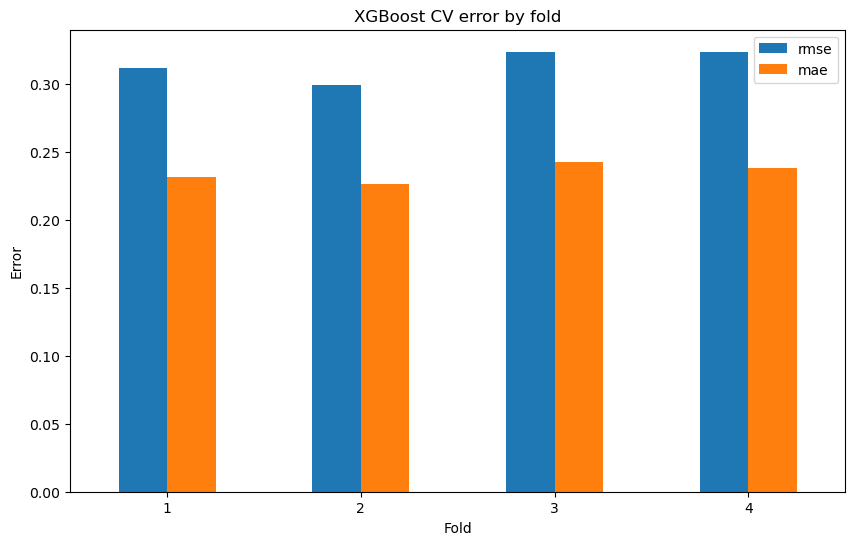

In [19]:
# Plot fold results for XGBoost

ax = cv_results_xgb.plot(
    x="fold",
    y=["rmse", "mae"],
    kind="bar",
    figsize=(10,6)
)

ax.set_title('XGBoost CV error by fold')
ax.set_xlabel('Fold')
ax.set_ylabel('Error')
plt.xticks(rotation=0)
plt.tight_layout
plt.show()

In [20]:
# Scenario specific performance of XGBoost

scenario_means_xgb = (
    scenario_cv_xgb
    .groupby("scenario")[["rmse", "mae", "r2"]]
    .mean()
    .reset_index()
)

scenario_means_xgb

,scenario,rmse,mae,r2
0,003,0.312660,0.230085,0.994911
1,004,0.323704,0.243971,0.994497
2,005,0.322616,0.242117,0.994621
3,006,0.313134,0.231748,0.994773
4,007,0.317651,0.240694,0.994833
5,008,0.290954,0.220839,0.995793


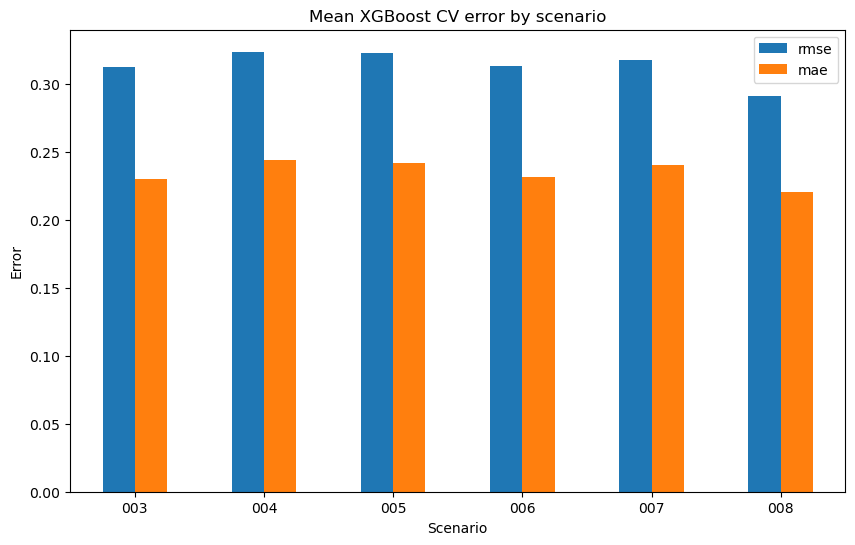

In [21]:
ax = scenario_means_xgb.plot(
    x="scenario",
    y=["rmse", "mae"],
    kind="bar",
    figsize=(10,6)
)

ax.set_title('Mean XGBoost CV error by scenario')
ax.set_xlabel('Scenario')
ax.set_ylabel('Error')
plt.xticks(rotation=0)
plt.tight_layout
plt.show()

In [22]:
# Monthly error summaries for XGBoost

monthly_error_summary = (
    val_preds_xgb
    .groupby("month")
    .agg(
        mae=("abs_error", "mean"),
        mse=("squared_error", "mean"),
        n=("abs_error", "size")
    )
    .reset_index()
)

monthly_error_summary["rmse"] = np.sqrt(monthly_error_summary["mse"])
monthly_error_summary = monthly_error_summary.drop(columns="mse")

monthly_error_summary

,month,mae,n,rmse
0,1,0.189992,5040,0.243623
1,2,0.213921,5040,0.281323
2,3,0.266710,5040,0.349465
3,4,0.291767,5040,0.384519
4,5,0.264039,5040,0.345557
5,6,0.233166,5040,0.302970
6,7,0.243650,5040,0.364076
7,8,0.227895,5040,0.314540
8,9,0.245341,5040,0.326936
9,10,0.222119,5040,0.298385


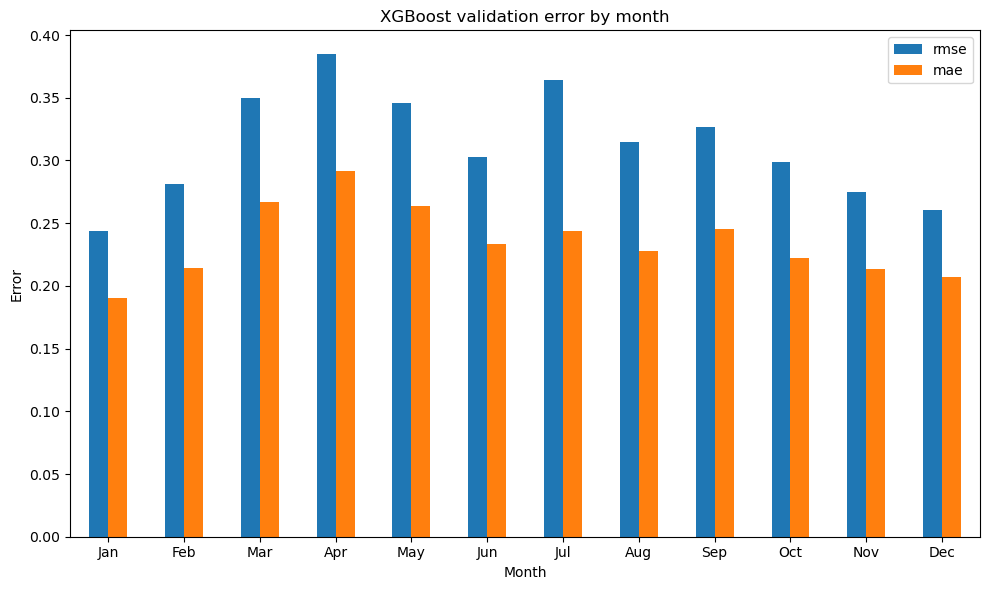

In [23]:
monthly_labels = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun",
    7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
}

monthly_error_summary["month_name"] = monthly_error_summary["month"].map(monthly_labels)

ax = monthly_error_summary.plot(
    x="month_name",
    y=["rmse", "mae"],
    kind="bar",
    figsize=(10, 6)
)

ax.set_title("XGBoost validation error by month")
ax.set_xlabel("Month")
ax.set_ylabel("Error")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [24]:
# Comparison to linear regression baseline

linear_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", LinearRegression())
])

results = []

for i, fold in enumerate(folds, start=1):
    train_mask = df["year"] <= fold["train_end_year"]
    val_mask = (df["year"] >= fold["val_start_year"]) & (df["year"] <= fold["val_end_year"])

    train_df = df.loc[train_mask].copy()
    val_df = df.loc[val_mask].copy()

    X_train = train_df[feature_cols]
    y_train = train_df[target]

    X_val = val_df[feature_cols]
    y_val = val_df[target]

    linear_pipeline.fit(X_train, y_train)
    y_pred = linear_pipeline.predict(X_val)

    results.append({
        "fold": i,
        **regression_metrics(y_val, y_pred)
    })

cv_results_lr = pd.DataFrame(results)
cv_results_lr

,fold,rmse,mae,r2
0,1,0.699597,0.545909,0.974827
1,2,0.649772,0.514718,0.977963
2,3,0.683019,0.534314,0.975603
3,4,0.708200,0.550343,0.975353


In [25]:
print("Linear regression mean CV metrics:")
print(cv_results_lr[["rmse", "mae", "r2"]].mean())

Linear regression mean CV metrics:
rmse    0.685147
mae     0.536321
r2      0.975936
dtype: float64


In [26]:
# Comparison to ridge regression baseline

ridge_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", Ridge(alpha=1.0))
])

results = []

for i, fold in enumerate(folds, start=1):
    train_mask = df["year"] <= fold["train_end_year"]
    val_mask = (df["year"] >= fold["val_start_year"]) & (df["year"] <= fold["val_end_year"])

    train_df = df.loc[train_mask].copy()
    val_df = df.loc[val_mask].copy()

    X_train = train_df[feature_cols]
    y_train = train_df[target]

    X_val = val_df[feature_cols]
    y_val = val_df[target]

    ridge_pipeline.fit(X_train, y_train)
    y_pred = ridge_pipeline.predict(X_val)

    results.append({
        "fold": i,
        **regression_metrics(y_val, y_pred)
    })

cv_results_ridge = pd.DataFrame(results)
cv_results_ridge

,fold,rmse,mae,r2
0,1,0.736804,0.577727,0.972078
1,2,0.692974,0.553030,0.974935
2,3,0.718721,0.562636,0.972986
3,4,0.749945,0.577207,0.972361


In [27]:
print("Ridge regression mean CV metrics:")
print(cv_results_ridge[["rmse", "mae", "r2"]].mean())

Ridge regression mean CV metrics:
rmse    0.724611
mae     0.567650
r2      0.973090
dtype: float64


In [28]:
# Model comparison

model_comparison = pd.DataFrame({
    "model": ["XGBoost", "LinearRegression", "Ridge"],
    "rmse": [
        cv_results_xgb["rmse"].mean(),
        cv_results_lr["rmse"].mean(),
        cv_results_ridge["rmse"].mean()
    ],
    "mae": [
        cv_results_xgb["mae"].mean(),
        cv_results_lr["mae"].mean(),
        cv_results_ridge["mae"].mean()
    ],
    "r2": [
        cv_results_xgb["r2"].mean(),
        cv_results_lr["r2"].mean(),
        cv_results_ridge["r2"].mean()
    ]
})

model_comparison

,model,rmse,mae,r2
0,XGBoost,0.314802,0.234909,0.994918
1,LinearRegression,0.685147,0.536321,0.975936
2,Ridge,0.724611,0.567650,0.973090


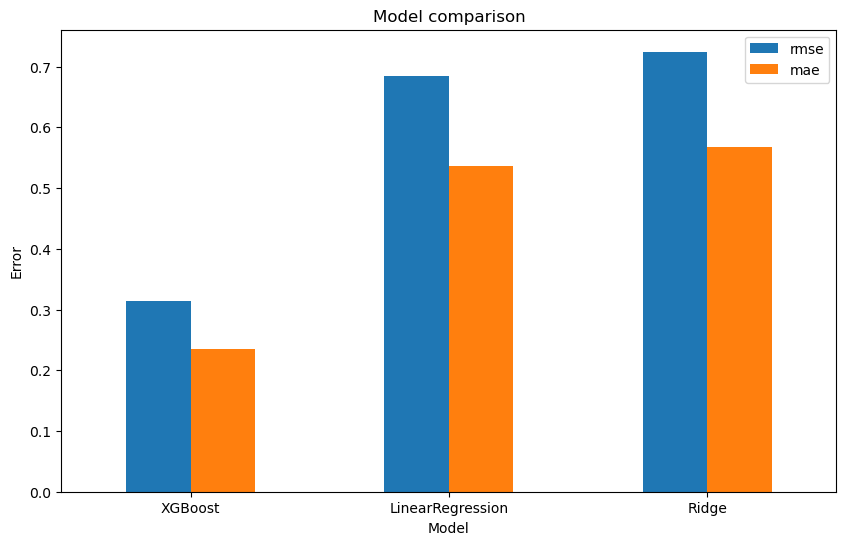

In [29]:
ax = model_comparison.plot(
    x="model",
    y=["rmse", "mae"],
    kind="bar",
    figsize=(10, 6)
)

ax.set_title("Model comparison")
ax.set_xlabel("Model")
ax.set_ylabel("Error")
plt.xticks(rotation=0)
plt.tight_layout
plt.show()

In [30]:
# Fit final XGBoost model on all pre-2050 data

train_final = df[df["year"] < 2050].copy()
post2050 = df[df["year"] >= 2050].copy()

X_train_final = train_final[feature_cols]
y_train_final = train_final[target]
X_post2050 = post2050[feature_cols]

xgb_pipeline.fit(X_train_final, y_train_final)
post2050 = post2050.copy()
post2050["pred_TREFMXAV_U"] = xgb_pipeline.predict(X_post2050)

post2050.head()

,scenario,time,TREFMXAV_U,TREFHT,FLNS,FSNS,PRECT,PRSN,QBOT,UBOT,...,monthly_cos,wind_speed,TREFHT_lag1,PRECT_lag1,PRSN_lag1,FLNS_lag1,FSNS_lag1,QBOT_lag1,wind_speed_lag1,pred_TREFMXAV_U
22176,003,2050-01-01 00:00:00,285.801361,283.996765,37.516384,30.577051,2.521736e-06,1.648166e-14,0.006410,5.582342,...,8.660254e-01,7.836511,282.483734,4.135034e-07,2.540881e-14,58.289959,34.724419,0.005628,2.141264,285.695190
22218,003,2050-02-01 00:00:00,285.415436,282.440613,66.326950,79.958450,8.721353e-07,3.524978e-14,0.005101,-0.701649,...,5.000000e-01,2.899583,283.996765,2.521736e-06,1.648166e-14,37.516384,30.577051,0.006410,7.836511,285.143158
22260,003,2050-03-01 00:00:00,284.608612,281.546753,60.539158,117.381302,7.776718e-07,7.428997e-10,0.004784,-1.219419,...,6.123234e-17,1.402428,282.440613,8.721353e-07,3.524978e-14,66.326950,79.958450,0.005101,2.899583,284.756958
22302,003,2050-04-01 00:00:00,289.549805,284.747833,59.838787,176.792770,9.672199e-07,2.614217e-14,0.005760,1.609725,...,-5.000000e-01,1.632368,281.546753,7.776718e-07,7.428997e-10,60.539158,117.381302,0.004784,1.402428,289.387787
22344,003,2050-05-01 00:00:00,294.813629,288.921021,66.239777,248.411362,2.893328e-07,2.476724e-15,0.007576,-2.432174,...,-8.660254e-01,3.282235,284.747833,9.672199e-07,2.614217e-14,59.838787,176.792770,0.005760,1.632368,294.004791


In [31]:
# Feature importance

xgb_model = xgb_pipeline.named_steps["model"]
feature_names = xgb_pipeline.named_steps["preprocess"].get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

importance_df.head(20)

,feature,importance
11,num__TREFHT,0.635155
22,num__FSNS_lag1,0.232008
16,num__QBOT,0.037847
10,num__monthly_cos,0.022930
15,num__PRSN,0.011809
13,num__FSNS,0.011462
6,num__lat,0.008407
14,num__PRECT,0.005991
21,num__FLNS_lag1,0.005643
9,num__monthly_sin,0.005148


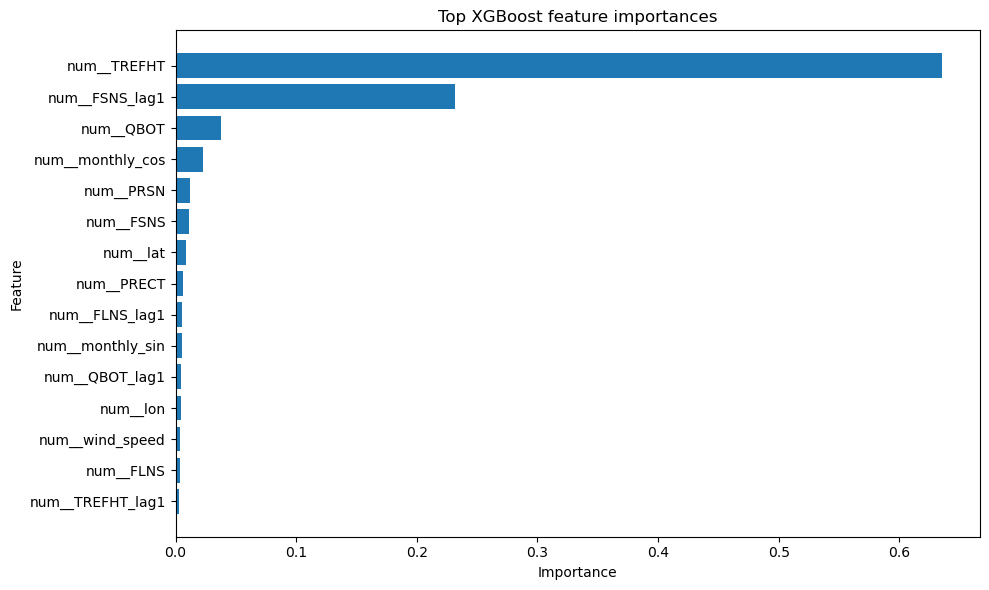

In [32]:
top_n = 15
plot_df = importance_df.head(top_n).sort_values("importance")

plt.figure(figsize=(10, 6))
plt.barh(plot_df["feature"], plot_df["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top XGBoost feature importances")
plt.tight_layout()
plt.show()

In [33]:
from src.config import TABLES_DIR

cv_results_xgb.to_csv(TABLES_DIR / "cv_results_xgb.csv", index=False)
scenario_cv_xgb.to_csv(TABLES_DIR / "scenario_cv_xgb.csv", index=False)
model_comparison.to_csv(TABLES_DIR / "model_comparison.csv", index=False)
importance_df.to_csv(TABLES_DIR / "importance_feature_importance.csv", index=False)
post2050.to_csv(TABLES_DIR / "post2050_predictions.csv", index=False)

## Summary:  

- XGBoost was stable across CV folds.
- Performance was broadly consistent across scenarios.
- Performance showed variation across months, with lowest errors in winter months. Highest errors seemed to occur in spring, particularly April.
- Suggests model captures cold-season conditions well but transition positions where more rapid temperature changes happen are more challenging.
- Secondary increase in error can be seen in summer months: indicates extra complexity in TREFMXAV_U in warm-season.
- April and July also see sharper increases in RMSE than MAE which suggests some higher magnitude misses in these months, perhaps caused by some larger outliers.
- XGBoost substantially outperformed linear and ridge regression baselines.
- Suggesting predictor-target relationship is nonlinear.
- Final post-2050 predictions generated using model fitted on all pre-2050 data.

# TREFHT ablation  

In [34]:
# Full feature version

full_feature_cols = [
    "scenario",
    "lat", "lon",
    "year",
    "monthly_sin", "monthly_cos",
    "TREFHT",
    "FLNS", "FSNS",
    "PRECT", "PRSN",
    "QBOT",
    "wind_speed",
    "TREFHT_lag1",
    "PRECT_lag1",
    "PRSN_lag1",
    "FLNS_lag1",
    "FSNS_lag1",
    "QBOT_lag1",
    "wind_speed_lag1"
]

# Reduced feature version to test sensitivity to TREFHT

reduced_feature_cols = [
    "scenario",
    "lat", "lon",
    "year",
    "monthly_sin", "monthly_cos",
    "FLNS", "FSNS",
    "PRECT", "PRSN",
    "QBOT",
    "wind_speed",
    "PRECT_lag1",
    "PRSN_lag1",
    "FLNS_lag1",
    "FSNS_lag1",
    "QBOT_lag1",
    "wind_speed_lag1"
]

In [35]:
# XGBoost CV (reusable function)

def run_xgb_cv(df, feature_cols, folds, target="TREFMXAV_U"):
    categorical_features = ["scenario"]
    numeric_features = [c for c in feature_cols if c not in categorical_features]

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
            ("num", "passthrough", numeric_features),
        ]
    )

    pipeline = Pipeline([
        ("preprocess", preprocessor),
        ("model", XGBRegressor(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            random_state=42,
        ))
    ])

    fold_results = []
    scenario_results = []
    all_val_predictions = []

    for i, fold in enumerate(folds, start=1):
        train_mask = df["year"] <= fold["train_end_year"]
        val_mask = (df["year"] >= fold["val_start_year"]) & (df["year"] <= fold["val_end_year"])

        train_df = df.loc[train_mask].copy()
        val_df = df.loc[val_mask].copy()

        X_train = train_df[feature_cols]
        y_train = train_df[target]
        X_val = val_df[feature_cols]
        y_val = val_df[target]

        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_val)

        fold_metrics = regression_metrics(y_val, y_pred)
        fold_results.append({
            "fold": i,
            "n_train": len(train_df),
            "n_val": len(val_df),
            **fold_metrics
        })

        val_df = val_df.copy()
        val_df["pred"] = y_pred
        val_df["fold"] = i
        val_df["abs_error"] = (val_df[target] - val_df["pred"]).abs()
        val_df["squared_error"] = (val_df[target] - val_df["pred"]) ** 2
        all_val_predictions.append(val_df)

        for scenario, grp in val_df.groupby("scenario"):
            scenario_metrics = regression_metrics(grp[target], grp["pred"])
            scenario_results.append({
                "fold": i,
                "scenario": scenario,
                "n": len(grp),
                **scenario_metrics
            })

    return {
        "pipeline": pipeline,
        "cv_results": pd.DataFrame(fold_results),
        "scenario_results": pd.DataFrame(scenario_results),
        "val_predictions": pd.concat(all_val_predictions, ignore_index=True)
    }

In [36]:
full_results = run_xgb_cv(df, full_feature_cols, folds, target=target)
reduced_results = run_xgb_cv(df, reduced_feature_cols, folds, target=target)

In [37]:
# Compare fold-level metrics

print("Full model mean CV metrics:")
print(full_results["cv_results"][["rmse", "mae", "r2"]].mean())

print("\nReduced model mean CV metrics:")
print(reduced_results["cv_results"][["rmse", "mae", "r2"]].mean())

Full model mean CV metrics:
rmse    0.314802
mae     0.234909
r2      0.994918
dtype: float64

Reduced model mean CV metrics:
rmse    0.464342
mae     0.342129
r2      0.988948
dtype: float64


In [38]:
trefht_comparison = pd.DataFrame({
    "model": ["With TREFHT", "Without TREFHT"],
    "rmse": [
        full_results["cv_results"]["rmse"].mean(),
        reduced_results["cv_results"]["rmse"].mean(),
    ],
    "mae": [
        full_results["cv_results"]["mae"].mean(),
        reduced_results["cv_results"]["mae"].mean(),
    ],
    "r2": [
        full_results["cv_results"]["r2"].mean(),
        reduced_results["cv_results"]["r2"].mean(),
    ]
})

trefht_comparison

,model,rmse,mae,r2
0,With TREFHT,0.314802,0.234909,0.994918
1,Without TREFHT,0.464342,0.342129,0.988948


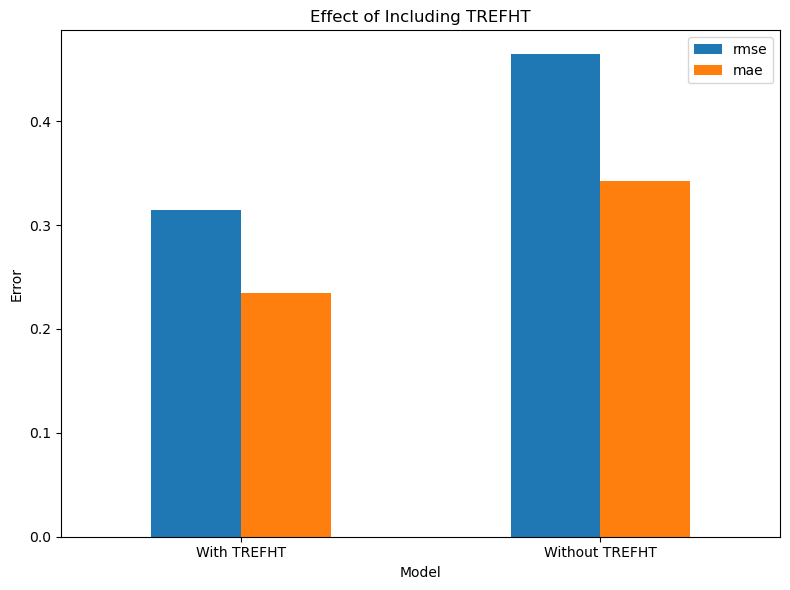

In [39]:
# Plot comparison

ax = trefht_comparison.plot(
    x="model",
    y=["rmse", "mae"],
    kind="bar",
    figsize=(8, 6)
)
ax.set_title("Effect of Including TREFHT")
ax.set_xlabel("Model")
ax.set_ylabel("Error")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [40]:
# Compare by scenario

full_scenario_means = (
    full_results["scenario_results"]
    .groupby("scenario")[["rmse", "mae", "r2"]]
    .mean()
    .reset_index()
)
full_scenario_means["model"] = "With TREFHT"

reduced_scenario_means = (
    reduced_results["scenario_results"]
    .groupby("scenario")[["rmse", "mae", "r2"]]
    .mean()
    .reset_index()
)
reduced_scenario_means["model"] = "Without TREFHT"

scenario_compare = pd.concat([full_scenario_means, reduced_scenario_means], ignore_index=True)
scenario_compare.head()

,scenario,rmse,mae,r2,model
0,003,0.312660,0.230085,0.994911,With TREFHT
1,004,0.323704,0.243971,0.994497,With TREFHT
2,005,0.322616,0.242117,0.994621,With TREFHT
3,006,0.313134,0.231748,0.994773,With TREFHT
4,007,0.317651,0.240694,0.994833,With TREFHT


In [41]:
# Pivot

scenario_rmse_compare = scenario_compare.pivot(index="scenario", columns="model", values="rmse")
scenario_rmse_compare

model,With TREFHT,Without TREFHT
scenario,,
003,0.312660,0.450321
004,0.323704,0.465835
005,0.322616,0.492455
006,0.313134,0.444873
007,0.317651,0.461502
008,0.290954,0.460644


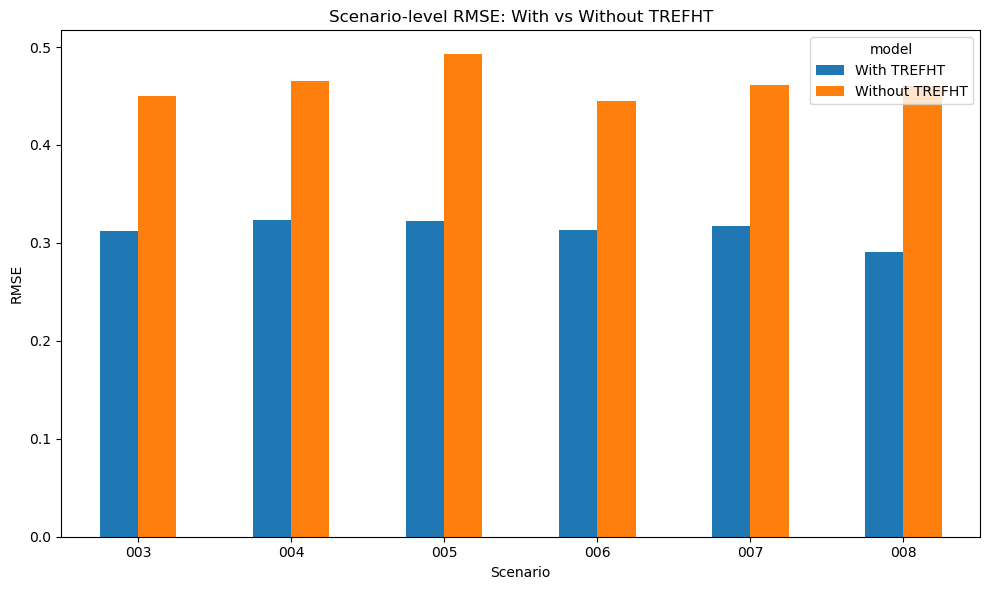

In [42]:
ax = scenario_rmse_compare.plot(kind="bar", figsize=(10, 6))
ax.set_title("Scenario-level RMSE: With vs Without TREFHT")
ax.set_xlabel("Scenario")
ax.set_ylabel("RMSE")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [43]:
# Also compare monthly error patterns

def monthly_error_summary(val_preds, target="TREFMXAV_U"):
    summary = (
        val_preds
        .groupby("month")
        .agg(
            mae=("abs_error", "mean"),
            mse=("squared_error", "mean"),
            n=("abs_error", "size")
        )
        .reset_index()
    )
    summary["rmse"] = np.sqrt(summary["mse"])
    return summary.drop(columns="mse")

monthly_full = monthly_error_summary(full_results["val_predictions"], target=target)
monthly_full["model"] = "With TREFHT"

monthly_reduced = monthly_error_summary(reduced_results["val_predictions"], target=target)
monthly_reduced["model"] = "Without TREFHT"

monthly_compare = pd.concat([monthly_full, monthly_reduced], ignore_index=True)
monthly_compare.head()

,month,mae,n,rmse,model
0,1,0.189992,5040,0.243623,With TREFHT
1,2,0.213921,5040,0.281323,With TREFHT
2,3,0.266710,5040,0.349465,With TREFHT
3,4,0.291767,5040,0.384519,With TREFHT
4,5,0.264039,5040,0.345557,With TREFHT


In [44]:
monthly_rmse_compare = monthly_compare.pivot(index="month", columns="model", values="rmse")
monthly_rmse_compare

model,With TREFHT,Without TREFHT
month,,
1,0.243623,0.350941
2,0.281323,0.347770
3,0.349465,0.459446
4,0.384519,0.647578
5,0.345557,0.638415
6,0.302970,0.577307
7,0.364076,0.539419
8,0.314540,0.444781
9,0.326936,0.375795


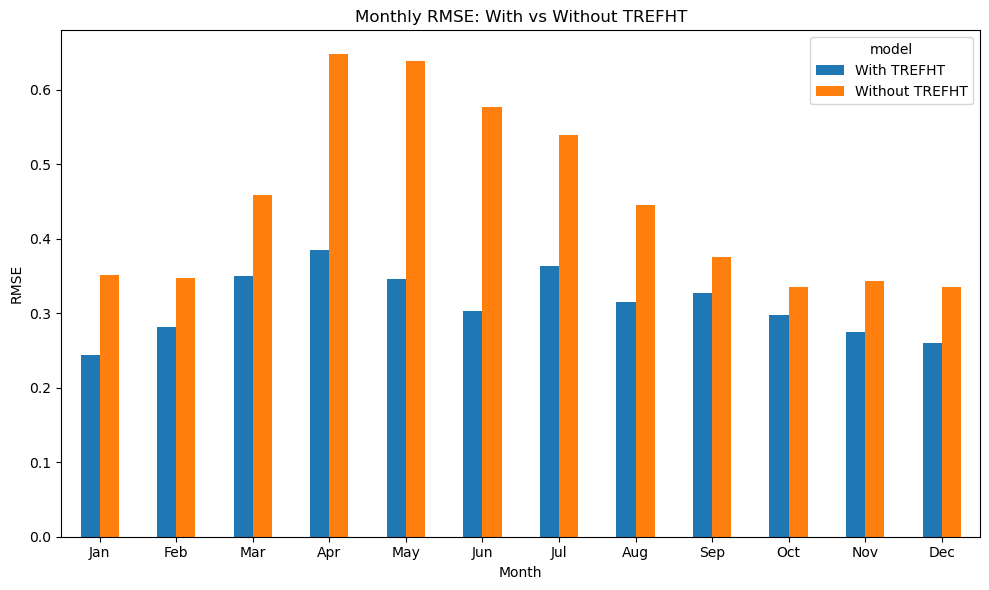

In [45]:
from src.config import FIGURES_DIR

month_labels = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
}

monthly_rmse_compare.index = monthly_rmse_compare.index.map(month_labels)

ax = monthly_rmse_compare.plot(kind="bar", figsize=(10, 6))
ax.set_title("Monthly RMSE: With vs Without TREFHT")
ax.set_xlabel("Month")
ax.set_ylabel("RMSE")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "trefht_ablation_rmse_monthly_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [46]:
trefht_comparison.to_csv(TABLES_DIR / "trefht_ablation_model_comparison.csv", index=False)
scenario_compare.to_csv(TABLES_DIR / "trefht_ablation_scenario_comparison.csv", index=False)
monthly_compare.to_csv(TABLES_DIR / "trefht_ablation_monthly_comparison.csv", index=False)

### Feature importance: full model vs reduced model:  


In [47]:
# Full model

full_model = full_results["pipeline"].named_steps["model"]
full_feature_names = full_results["pipeline"].named_steps["preprocess"].get_feature_names_out()

full_importance_df = pd.DataFrame({
    "feature": full_feature_names,
    "importance": full_model.feature_importances_
}).sort_values("importance", ascending=False)

full_importance_df.head(20)

,feature,importance
11,num__TREFHT,0.630721
22,num__FSNS_lag1,0.236171
16,num__QBOT,0.035735
10,num__monthly_cos,0.022254
15,num__PRSN,0.015224
13,num__FSNS,0.011188
6,num__lat,0.008735
9,num__monthly_sin,0.006130
21,num__FLNS_lag1,0.005593
14,num__PRECT,0.005456


In [48]:
# Reduced model

reduced_model = reduced_results["pipeline"].named_steps["model"]
reduced_feature_names = reduced_results["pipeline"].named_steps["preprocess"].get_feature_names_out()

reduced_importance_df = pd.DataFrame({
    "feature": reduced_feature_names,
    "importance": reduced_model.feature_importances_
}).sort_values("importance", ascending=False)

reduced_importance_df.head(20)

,feature,importance
20,num__FSNS_lag1,0.549327
15,num__QBOT,0.164220
10,num__monthly_cos,0.155904
9,num__monthly_sin,0.027159
14,num__PRSN,0.025194
12,num__FSNS,0.017393
21,num__QBOT_lag1,0.017326
6,num__lat,0.013458
13,num__PRECT,0.007326
7,num__lon,0.004665


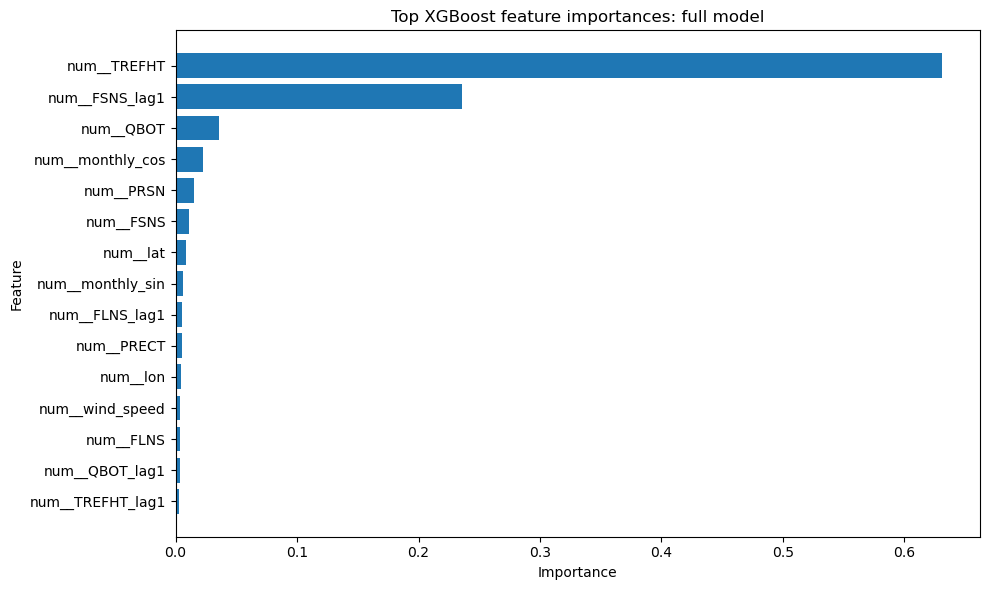

In [49]:
top_n = 15
plot_df = full_importance_df.head(top_n).sort_values("importance")

plt.figure(figsize=(10, 6))
plt.barh(plot_df["feature"], plot_df["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top XGBoost feature importances: full model")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "xgb_feature_importance_full_model.png", dpi=300, bbox_inches="tight")
plt.show()

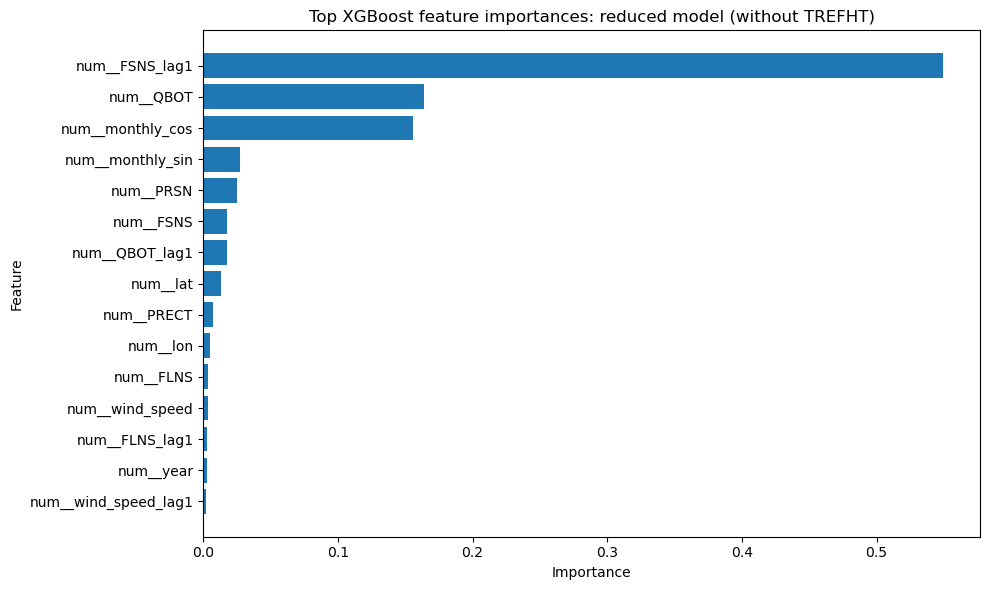

In [50]:
top_n = 15
plot_df = reduced_importance_df.head(top_n).sort_values("importance")

plt.figure(figsize=(10, 6))
plt.barh(plot_df["feature"], plot_df["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top XGBoost feature importances: reduced model (without TREFHT)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "xgb_feature_importance_reduced_model.png", dpi=300, bbox_inches="tight")
plt.show()

In [51]:
full_importance_df.to_csv(TABLES_DIR / "xgb_feature_importance_full_model.csv", index=False)
reduced_importance_df.to_csv(TABLES_DIR / "xgb_feature_importance_reduced_model.csv", index=False)

# TREFHT ablation summary:  

- Model performance noticeable worsens when TREFHT and related lag feature are removed, indicating model relies on TREFHT heavily
- Logical given that this is strongly related to TREFMXAV_U
- However, model does not collapse entirely, indicating other climate variables do also carry useful signal
- Model performance worsens across all scenarios in a largely consistent way
- Season model performance is substantially worse in the spring/summer months that were previously identified as having greatest errors in full model
- Indicates TREFHT is even more important for predictions in 'difficult' months

## Interpreting predictor importance

Feature importance from the full XGBoost model indicates which variables contributed most strongly to prediction of `TREFMXAV_U`. To avoid relying only on the model with `TREFHT` included, we also examined feature importance for the reduced model excluding `TREFHT` and `TREFHT_lag1`.

This helps distinguish between:
- predictors that dominate when a closely related temperature variable is available, and
- predictors that become important when prediction must rely more strongly on radiation, moisture, wind, seasonality, scenario, and lagged structure.

#### Feature importance summary  

The full-model feature importance results suggest that `TREFHT` is one of the dominant predictors of `TREFMXAV_U`. This is consistent with the ablation result, where removing `TREFHT` increased RMSE from about 0.315 to about 0.464.

However, the reduced-model importance results show that other predictors (like `FSNS_lag1`, `QBOT`, `monthly_cos`) still contribute meaningfully, indicating that projected variation in `TREFMXAV_U` is not explained by `TREFHT` alone.